# YiXi — corpus-level results

Automated corpus results for the Mandarin YiXi (一席) corpus. Everything here is
**collection level**: one number per corpus, built from all its videos, not per
talk. Sections deliberately mirror `01_tedx_trends.ipynb` one-for-one, so the
two can be read side by side and the comparative notebook has matching inputs.

Sections map onto the specification:

| here | spec | note |
|---|---|---|
| 3 | §2 Most frequent words | normalised per 1,000 segmented words, with dispersion |
| 4 | §5 Wrist velocity | body-normalised, replacing the pixel metric |
| 5 | §4 Pitch level and variation | speaker-relative, in semitones |
| 6 | §3 Shots and angles | within-corpus percentages |

**Deliberately elsewhere.** Keyness (§2's EN–ZH comparison step), the shot
chi-square (§3) and the EN–ZH concept mapping (§7.3) belong to the comparative
notebook — they are two-corpus statistics and cannot be computed here.
Cross-modal correlation (§6) is in `04_multimodal_coupling.ipynb`.

## Four things differ from the English notebook, for reasons of language

These are not stylistic choices; each one would produce a wrong number if
carried over unchanged from notebook 01.

1. **A "word" is a segmentation decision.** Chinese is written without spaces,
   so the token counts here come from pkuseg (via spaCy's `zh_core_web_sm`)
   upstream. A different segmenter gives different frequencies for the same
   audio, which belongs in any methods section.
2. **Content parts of speech do not isolate content words.** Restricting to
   NOUN/VERB/ADJ in English removes function words; in Chinese it does not,
   because 是 (copula), 有 (existential) and 就/也/都 (particles and adverbs)
   are tagged VERB and ADV. Section 3 uses an explicit, listed stop list
   instead.
3. **The stored speech rate is wrong for this corpus by roughly half again**,
   and section 3 counts syllables instead. See that section for the arithmetic.
4. **Pitch variation is partly lexical tone.** Mandarin is tonal, so f0
   movement here is not the same construct as f0 movement in English, and the
   two corpora's `pitch_variation` are not directly comparable.

One thing is unreliable in **both** notebooks: the part-of-speech tag attached
to each word. The upstream word list records the tag of a word's *first*
occurrence in a video and then counts every later occurrence under it
(`workers/verbal_worker.py`), so a tag is a sample of one token, not a
distribution. This notebook therefore reports frequencies with parts of speech
merged, and never splits a count by tag.

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import _corpus as C

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({
    "figure.figsize": (11, 3.2), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
})

# Every word and video label in this corpus is Chinese, and matplotlib's
# default font has no Han glyphs — without this every label renders as empty
# boxes. Checked rather than assumed, because a missing font is silent.
CJK_FONTS = ["Noto Sans CJK SC", "Noto Sans CJK TC", "Source Han Sans SC",
             "WenQuanYi Zen Hei", "Microsoft YaHei", "PingFang SC",
             "Droid Sans Fallback"]
available = {f.name for f in font_manager.fontManager.ttflist}
chosen = next((f for f in CJK_FONTS if f in available), None)
if chosen:
    plt.rcParams["font.sans-serif"] = [chosen] + list(plt.rcParams["font.sans-serif"])
    plt.rcParams["axes.unicode_minus"] = False
    print(f"CJK font: {chosen}")
else:
    print("WARNING — no CJK font found. Chinese labels will render as boxes.\n"
          "  Install one, e.g.  sudo pacman -S noto-fonts-cjk   /   apt install fonts-noto-cjk\n"
          "  then delete ~/.cache/matplotlib and restart the kernel.")

MODALITY_COLOUR = {"gesture": "#C84B31", "prosody": "#2D6A4F",
                   "verbal": "#1B4F8A", "camera": "#7B5EA7"}


def short_label(s, n=30):
    # Video labels carry the source filename; the extension is not information.
    s = str(s).strip()
    for ext in (".mp4", ".mkv", ".webm", ".mov"):
        if s.lower().endswith(ext):
            s = s[: -len(ext)]
    return s[:n]


CORPUS = "YiXi"

print("corpora present in MongoDB:", C.available_corpora())

CJK font: Noto Sans CJK SC


corpora present in MongoDB: ['TedX', 'Yixi']


## 1. Does this corpus have data?

In [2]:
# One download for every section below: videos, windows (with the pitch and
# normalised-gesture columns already merged in) and the per-video word lists.
# Cached on disk under $WORK_DIR/corpus_cache and keyed by the corpus' job ids
# and window counts, so adding, reprocessing or deleting a video invalidates it
# automatically. refresh=True forces a re-fetch; offline=True trusts the cache
# without contacting MongoDB, for working through an Atlas outage.
data = C.load_corpus(CORPUS, refresh=True)

videos = data.videos
df = data.windows
HAS_DATA = not df.empty and not videos.empty

print(data)
print(f"\n{len(df)} windows across {df.job_id.nunique() if HAS_DATA else 0} videos"
      f"  |  {videos.duration_s.sum()/60:.0f} min of footage" if HAS_DATA else "no data")

# Same talk shipped twice under different job ids would double-count every
# statistic below. load_videos catches one job on two shards; this catches two
# jobs holding the same talk, which a re-ship with a changed drive_url can do.
if HAS_DATA:
    dupes = videos[videos.duplicated("label", keep=False)].sort_values("label")
    if not dupes.empty:
        print("\nWARNING — duplicate labels (same talk stored twice?):")
        print(dupes[["job_id", "label", "total_windows"]].to_string(index=False))

    # YiXi labels are numbered by hand, so a gap is the quickest check that a
    # video failed to ship rather than simply not existing. Reported, not
    # fixed: a gap may equally mean the talk was never in the sample.
    import re as _re
    nums = sorted(int(m.group(1)) for lab in videos.label.fillna("")
                  if (m := _re.match(r"\s*(\d+)", str(lab))))
    if nums:
        missing = sorted(set(range(min(nums), max(nums) + 1)) - set(nums))
        print(f"\nlabel numbering runs {min(nums)}–{max(nums)} over {len(nums)} videos"
              + (f"; absent: {missing}" if missing else "; no gaps"))

/home/abx13/Prog/Mannerism-Analyzer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading Yixi: 0/4 |          | 

loading Yixi: 0/4 |          | , windows

loading Yixi: 1/4 |██▌       | , windows

loading Yixi: 1/4 |██▌       | , pitch  

...

  keyframes: 100%|██████████| 29/29 [00:15<00:00,  1.73it/s]

loading Yixi: 3/4 |███████▌  | , gesture  

loading Yixi: 4/4 |██████████| , gesture

loading Yixi: 4/4 |██████████| , gesture

cached to /tmp/mannerism/corpus_cache/Yixi_5fbcf6b6634bd4c8.pkl
<CorpusData Yixi: 29 videos, 10829 windows, 9928 with normalised gesture, 37814 per-video word rows>

10829 windows across 29 videos  |  901 min of footage

label numbering runs 1–29 over 29 videos; no gaps


## 2. Coverage — how much of each measurement exists

Read this before any number below. A confident-looking mean over 12% of
windows is not a corpus result.

Gesture rows are missing wherever the pipeline found no pose — scenes showing
the audience, the slides, or a shot too wide to track. Those windows are NaN,
not zero, so they are excluded rather than averaged in as "held perfectly
still".

In [3]:
if not HAS_DATA:
    print("skipped — no data")
else:
    display(C.coverage_report(df).head(20))
    print(f"pose present in {df.pose_present_ratio.gt(0).mean():.0%} of windows; "
          f"mean coverage within those: {df.loc[df.pose_present_ratio>0,'pose_present_ratio'].mean():.2f}")

,non_null,total,coverage
face_bbox_trend,9298,10829,0.859
mean_face_bbox_area,9668,10829,0.893
n_samples,9928,10829,0.917
wrist_speed_mean,9928,10829,0.917
wrist_speed_p90,9928,10829,0.917
wrist_speed_max,9928,10829,0.917
max_wrist_displacement,10046,10829,0.928
handedness_ratio,10046,10829,0.928
vertical_angle,10046,10829,0.928
horizontal_angle,10046,10829,0.928


pose present in 93% of windows; mean coverage within those: 0.95


## 3. Most frequent words  — spec §2

Counts are normalised two ways, because "frequency per 1,000 tokens" is
ambiguous between them and they answer different questions:

* **`freq_per_1000`** — pooled over the corpus. Every *token* weighs the same,
  so a 41-minute talk contributes more than a 21-minute one.
* **`mean_video_freq`** — each video's own rate, averaged. Every *speaker*
  weighs the same.

Where they disagree, one talk is driving the word. `n_videos` and `range_pct`
(document frequency) make that explicit: a word appearing 200 times in one talk
and nowhere else is a property of that speaker, not of YiXi.

### What a token is here

Both figures are per 1,000 **spaCy-segmented words**, not per 1,000 characters
and not per 1,000 ASR tokens. Mandarin is written without spaces, so word
boundaries are produced by pkuseg inside `zh_core_web_sm`. The recogniser emits
roughly one token per character — 234k tokens, of which 209k are Han characters
— and re-segmenting them yields about 130k words. Quoting a rate against the
recogniser's total rather than the segmenter's changes every number by about
1.8×, which is what this notebook's loader used to do.

Rows have parts of speech **merged** (`by_pos=False`). The upstream word list
stores the tag of a word's first occurrence in each video and then counts all
its occurrences under that tag, so a per-tag count is not a count of that
grammatical use — 一个 is filed under five different tags across the 26 talks,
one per video, with the video sets perfectly disjoint. The merged counts are
unaffected and are what this section uses.

In [4]:
if not HAS_DATA:
    print("skipped — no data")
else:
    wl = data.wordlist(by_pos=False)
    print(f"{len(wl)} word types over {wl.attrs['corpus_tokens']:,.0f} segmented words "
          f"from {wl.attrs['n_videos']} videos")
    display(wl.head(30)[["word", "count", "freq_per_1000",
                         "mean_video_freq", "n_videos", "range_pct"]].round(2))

13082 word types over 145,149 segmented words from 29 videos


,word,count,freq_per_1000,mean_video_freq,n_videos,range_pct
0,的,11695,80.57,81.31,29,100.00
1,是,3352,23.09,23.15,29,100.00
2,这个,2684,18.49,17.66,29,100.00
3,我,2548,17.55,18.08,29,100.00
4,在,2490,17.15,17.37,29,100.00
5,了,2458,16.93,17.39,29,100.00
6,他,2145,14.78,14.45,29,100.00
7,呢,2030,13.99,13.79,29,100.00
8,一个,1906,13.13,12.79,29,100.00
9,我们,1750,12.06,11.77,29,100.00


### Content words — why the English recipe does not transfer

Notebook 01 isolates content words by keeping NOUN, PROPN, VERB, ADJ and ADV.
That works in English because its function words are closed-class tags
(DET, ADP, PRON, AUX). In Chinese it does not: the ten most frequent
"content-POS" items in this corpus are 是, 就, 有, 不, 也, 一个, 都, 就是, 说
and 那 — a copula, an existential verb, a negator, several particles and a
classifier phrase. A POS filter alone would present that list as the corpus'
subject matter.

So the cut here is an **explicit stop list**, written out in the cell below so
that a reader can see and change exactly what was removed. Three decisions in
it are worth stating:

* **Pronouns are kept.** In most corpus work they would be stopped, but this
  corpus is about gender and agency, so 我 / 我们 / 他 / 她 and their
  distribution are findings rather than noise.
* **被 is kept.** It is a grammatical passive marker, not a content word, but
  who is placed in the patient position is precisely what the flagging system
  asks about.
* **ASR fillers are removed** — 呃, 嗯, 啊, 呢. These are transcription of
  disfluency, and 呃 alone occurs 614 times across 24 talks. They are an
  artefact of the recogniser's verbosity, not vocabulary.

This is a display choice, not a statistical one, so the unfiltered list above
stays available.

stop list removes 103 types, 59,859 tokens (41.2% of the corpus)
  most frequent removed: 的  是  这个  在  了  呢  一个  就  有  啊  也  一


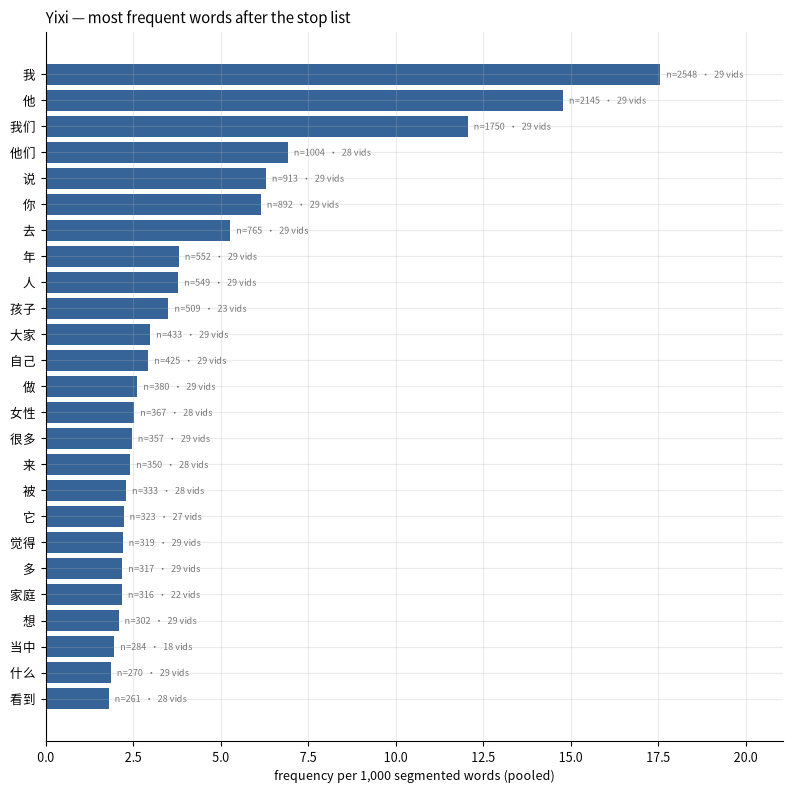

,word,count,freq_per_1000,mean_video_freq,n_videos,range_pct
3,我,2548,17.55,18.08,29,100.00
6,他,2145,14.78,14.45,29,100.00
9,我们,1750,12.06,11.77,29,100.00
16,他们,1004,6.92,7.31,28,96.55
18,说,913,6.29,5.99,29,100.00
20,你,892,6.15,5.82,29,100.00
24,去,765,5.27,5.22,29,100.00
36,年,552,3.80,3.89,29,100.00
37,人,549,3.78,3.87,29,100.00
41,孩子,509,3.51,4.29,23,79.31


In [5]:
# Grouped so each removal is auditable. Add to or delete from these and re-run.
ZH_PARTICLES  = ["的", "了", "着", "过", "地", "得", "把", "所", "之", "者", "以"]
ZH_FILLERS    = ["呃", "嗯", "啊", "呢", "吧", "吗", "哦", "嘛", "哎", "唉", "诶"]
ZH_COPULA     = ["是", "就是", "有", "没有", "会", "要", "能", "可以", "可能", "不是"]
ZH_DEIXIS     = ["这", "那", "这个", "那个", "这些", "那些", "这样", "那样",
                 "这种", "那种", "这里", "那里", "一个", "一", "个", "种", "些",
                 "一些", "一样", "里面", "里", "上", "下", "中", "时候"]
ZH_CONNECT    = ["在", "到", "和", "跟", "与", "或", "但", "但是", "因为", "所以",
                 "然后", "而且", "如果", "就", "也", "都", "还", "又", "而",
                 "对", "给", "让", "从", "为", "被", "比", "向", "于", "当",
                 "那么", "这么"]
ZH_DEGREE     = ["很", "非常", "太", "更", "最", "其实", "特别", "真的", "还是",
                 "已经", "就会", "不", "没", "别", "挺", "比较"]

# Kept deliberately — see the note above.
ZH_KEEP = {"我", "我们", "你", "你们", "他", "她", "它", "他们", "她们", "它们",
           "自己", "大家", "被"}

ZH_STOP = (set(ZH_PARTICLES) | set(ZH_FILLERS) | set(ZH_COPULA) | set(ZH_DEIXIS)
           | set(ZH_CONNECT) | set(ZH_DEGREE)) - ZH_KEEP

if HAS_DATA:
    content = wl[~wl.word.isin(ZH_STOP)].copy()
    removed = wl[wl.word.isin(ZH_STOP)]
    share = removed["count"].sum() / wl["count"].sum()
    print(f"stop list removes {len(ZH_STOP)} types, {removed['count'].sum():,.0f} tokens "
          f"({share:.1%} of the corpus)")
    print("  most frequent removed:",
          "  ".join(removed.head(12).word.tolist()))

    top = content.head(25).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.barh(top.word, top.freq_per_1000, color=MODALITY_COLOUR["verbal"], alpha=0.88)
    ax.set_xlabel("frequency per 1,000 segmented words (pooled)")
    ax.set_title(f"{CORPUS} — most frequent words after the stop list", loc="left")
    for y, (_, r) in enumerate(top.iterrows()):
        ax.text(r.freq_per_1000, y, f"   n={int(r['count'])}  ·  {int(r.n_videos)} vids",
                fontsize=6.5, color="0.45", va="center")
    ax.margins(x=0.20)
    plt.tight_layout(); plt.show()

    display(content.head(25)[["word", "count", "freq_per_1000", "mean_video_freq",
                              "n_videos", "range_pct"]].round(2))

### Dispersion — corpus word or one speaker's word?

Each point is a word that survived the stop list: how often it occurs against
how many videos carry it. Words low and to the left of the mass are frequent
*because of one talk*. Anything used for a corpus-level claim should sit high
on the vertical axis.

Expect this to matter more here than in the English corpus. YiXi talks are
single-topic and long, so a speaker on 土地权益 or 海盗 will push a handful of
domain nouns high in the pooled frequency list on her own.

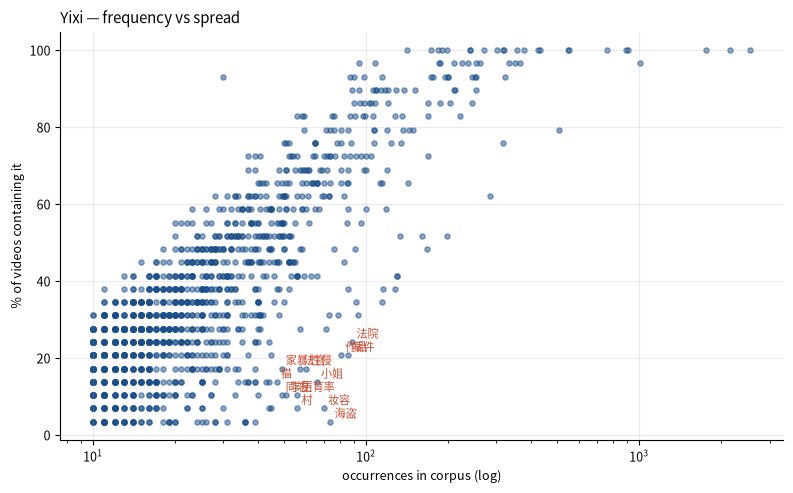

frequent but concentrated in few videos — treat as speaker-specific:


,word,count,n_videos,range_pct
195,法院,89,7,24.137931
210,案件,86,6,20.689655
218,作品,81,6,20.689655
233,海盗,74,1,3.448276
246,妆容,70,2,6.896552
254,小姐,66,4,13.793103
272,性侵,60,5,17.241379
289,法官,57,5,17.241379
292,生育率,56,3,10.344828
299,村,56,2,6.896552


In [6]:
if HAS_DATA:
    sub = content[content["count"] >= 10]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(sub["count"], sub.range_pct, s=14, alpha=0.5,
               color=MODALITY_COLOUR["verbal"])
    ax.set_xscale("log")
    ax.set_xlabel("occurrences in corpus (log)"); ax.set_ylabel("% of videos containing it")
    ax.set_title(f"{CORPUS} — frequency vs spread", loc="left")

    narrow = sub[(sub.range_pct < 25) & (sub["count"] >= 30)].head(14)
    for _, r in narrow.iterrows():
        ax.annotate(r.word, (r["count"], r.range_pct), fontsize=8,
                    xytext=(3, 3), textcoords="offset points", color="#C84B31")
    plt.tight_layout(); plt.show()

    if not narrow.empty:
        print("frequent but concentrated in few videos — treat as speaker-specific:")
        display(narrow[["word", "count", "n_videos", "range_pct"]])

### Speech rate  — counted, not assumed

`speech_rate_syl_per_s` is the number of Han characters in the window divided
by its duration. One character is one syllable in Mandarin, so this is a count
rather than an estimate, and the shaded band marks the 4–5.5 syl/s that the
literature reports for the language.

It was not always this. The field used to be `word_count / duration * 1.5`,
where 1.5 is an assumed syllables-per-word ratio for English — applied to a
recogniser count that was *already* one token per character, so it inflated
this corpus by about 1.66× and put its median at 7.2 syl/s. Both halves are
fixed in `core/fusion_engine.py`, and every video has been rebuilt through
`scripts/backfill_verbal.py`.

**It still does not travel to the English corpus.** There the ×1.5 estimate
remains, because counting English syllables needs a pronunciation dictionary.
Two different instruments, so `03_tedx_vs_yixi.ipynb` excludes speech rate from
its comparison. See `notebooks/DECISIONS.md` §3.

median 4.40 syl/s   IQR 3.60–5.00   over 10,829 windows in 29 videos


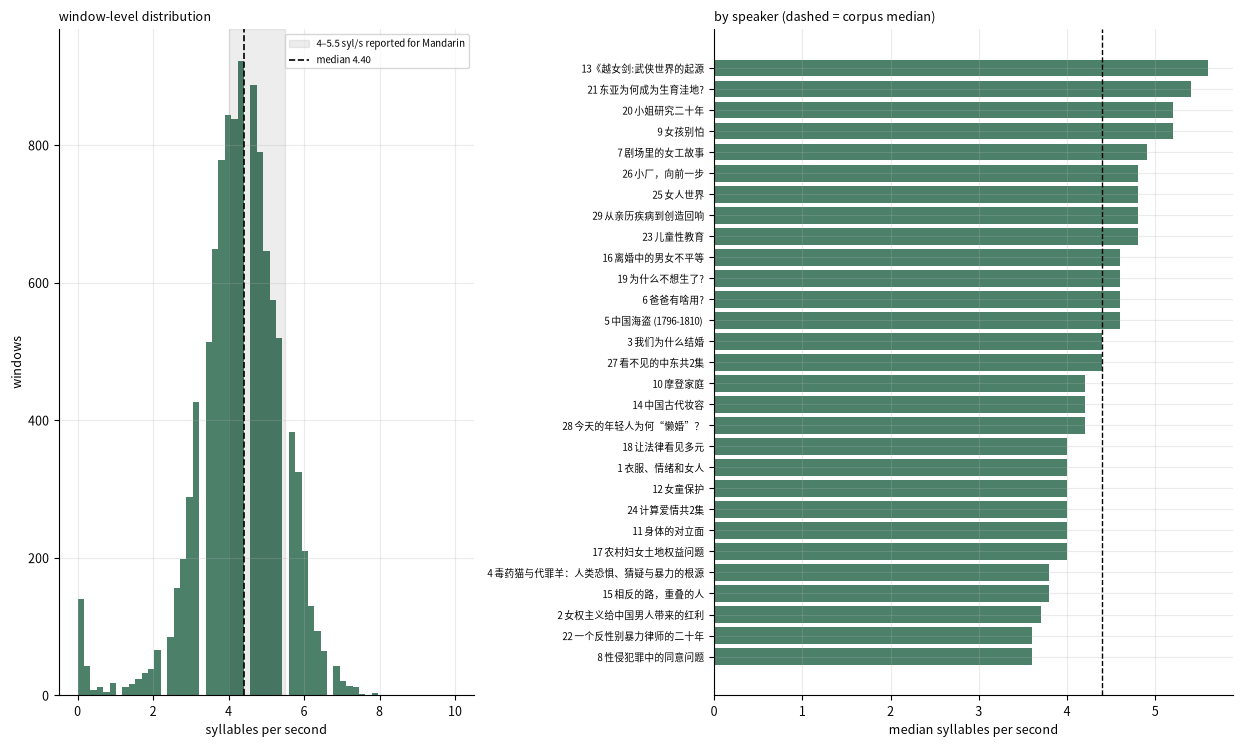

speakers range 3.60–5.60 syl/s (1.6x between slowest and fastest)


In [7]:
if not HAS_DATA:
    print("skipped — no data")
else:
    rate = df["speech_rate_syl_per_s"].dropna()
    per_video = (df.groupby("job_id").speech_rate_syl_per_s.median()
                 .reset_index()
                 .merge(videos[["job_id", "label"]], on="job_id", how="left")
                 .sort_values("speech_rate_syl_per_s"))
    per_video["label"] = per_video.label.fillna(per_video.job_id).map(short_label)

    print(f"median {rate.median():.2f} syl/s   "
          f"IQR {rate.quantile(.25):.2f}–{rate.quantile(.75):.2f}   "
          f"over {len(rate):,} windows in {df.job_id.nunique()} videos")

    fig, axes = plt.subplots(1, 2, figsize=(12.5, max(3.4, 0.26 * len(per_video))),
                             gridspec_kw={"width_ratios": [1, 1.25]})

    # window-level distribution, against the range reported for Mandarin
    axes[0].hist(rate, bins=np.linspace(0, 10, 60),
                 color=MODALITY_COLOUR["prosody"], alpha=0.85)
    axes[0].axvspan(4, 5.5, color="k", alpha=0.07,
                    label="4–5.5 syl/s reported for Mandarin")
    axes[0].axvline(rate.median(), color="k", lw=1.2, ls="--",
                    label=f"median {rate.median():.2f}")
    axes[0].set_xlabel("syllables per second"); axes[0].set_ylabel("windows")
    axes[0].legend(fontsize=7)
    axes[0].set_title("window-level distribution", loc="left", fontsize=9)

    # one number per speaker — the honest n for any comparison
    axes[1].barh(per_video.label, per_video.speech_rate_syl_per_s,
                 color=MODALITY_COLOUR["prosody"], alpha=0.85)
    axes[1].axvline(rate.median(), color="k", lw=1, ls="--")
    axes[1].set_xlabel("median syllables per second")
    axes[1].tick_params(axis="y", labelsize=7)
    axes[1].set_title("by speaker (dashed = corpus median)", loc="left", fontsize=9)
    plt.tight_layout(); plt.show()

    spread = per_video.speech_rate_syl_per_s
    print(f"speakers range {spread.min():.2f}–{spread.max():.2f} syl/s "
          f"({spread.max()/spread.min():.1f}x between slowest and fastest)")

## 4. Gesture magnitude, body-normalised  — spec §5

The stored `mean_wrist_velocity` is **pixels per second**, which confounds
gesture size with shot scale (a close-up makes the same movement sweep more
pixels) and with video resolution. §5 asks for normalisation "relative to body
scale in frame", which is what `load_corpus` computes (via `wrist_speed_series`):
wrist displacement divided by the speaker's own shoulder width and torso height,
per axis, from the dense pose keyframes. Units are **shoulder-widths per second**.

Per-axis matters: `pose_x` is normalised by frame width and `pose_y` by frame
height, so on 16:9 footage vertical distances are inflated ~1.78× before any
body scaling.

No reprocessing is needed — the keyframes were already stored. This is
identical to notebook 01's section 4; nothing about it is language-specific,
which is the point of running it on both corpora.

In [8]:
if not HAS_DATA:
    print("skipped — no data")
else:
    gest = data.gesture
    dfg = df                      # load_corpus already merged the gesture columns
    print(f"{len(gest)} windows with a normalised gesture measure "
          f"({gest.job_id.nunique()} videos)")
    display(gest[["wrist_speed_mean", "wrist_speed_p90", "wrist_speed_max"]]
            .describe().T[["count", "mean", "50%", "75%", "max"]].round(2))

9928 windows with a normalised gesture measure (29 videos)


,count,mean,50%,75%,max
wrist_speed_mean,9928.0,0.95,0.79,1.20,11.51
wrist_speed_p90,9928.0,1.56,1.25,1.90,37.96
wrist_speed_max,9928.0,9.33,3.11,9.82,290.42


### Does the normalisation actually remove the framing confound?

The test that matters, not an assumption: correlate each gesture metric with
`mean_face_bbox_area`, which is a direct proxy for how close the shot is. The
pixel metric should correlate with it; the body-normalised one should not.

,metric,rho vs shot scale,n
0,pixels/s (stored),0.564,9354
1,shoulder-widths/s (normalised),0.198,9252
2,"shoulder-widths/s, 90th pct",0.203,9252


closer to 0 = less contaminated by how close the camera is


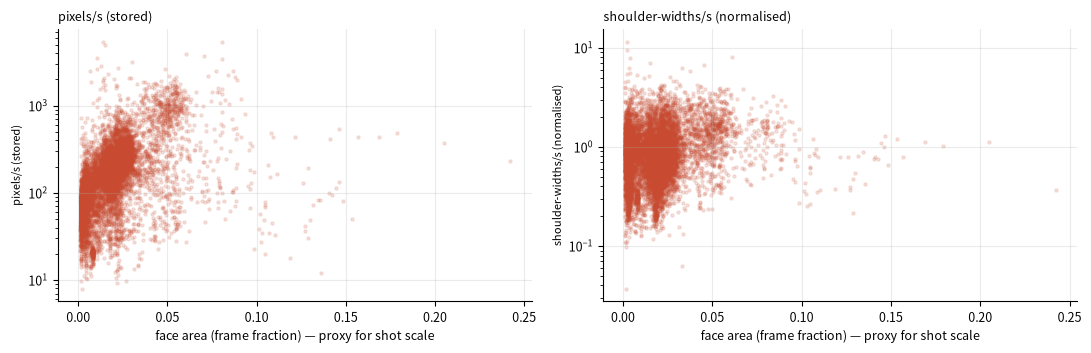

In [9]:
from scipy.stats import spearmanr

if HAS_DATA:
    checks = [("mean_wrist_velocity", "pixels/s (stored)"),
              ("wrist_speed_mean", "shoulder-widths/s (normalised)"),
              ("wrist_speed_p90", "shoulder-widths/s, 90th pct")]
    rows = []
    for col, label in checks:
        sub = dfg[[col, "mean_face_bbox_area"]].dropna()
        if len(sub) > 30:
            rho = spearmanr(sub[col], sub.mean_face_bbox_area).statistic
            rows.append({"metric": label, "rho vs shot scale": round(rho, 3), "n": len(sub)})
    display(pd.DataFrame(rows))
    print("closer to 0 = less contaminated by how close the camera is")

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for ax, (col, label) in zip(axes, checks[:2]):
        sub = dfg[[col, "mean_face_bbox_area"]].dropna()
        ax.scatter(sub.mean_face_bbox_area, sub[col], s=5, alpha=0.15,
                   color=MODALITY_COLOUR["gesture"])
        ax.set_yscale("log")
        ax.set_xlabel("face area (frame fraction) — proxy for shot scale")
        ax.set_ylabel(label, fontsize=8)
        ax.set_title(label, loc="left", fontsize=9)
    plt.tight_layout(); plt.show()

### Per-speaker gesture magnitude

§5 also asks for per-speaker normalisation for "individual differences in
movement amplitude". Shown rather than applied: the spread *between* speakers
is itself a result, and averaging it away would hide it. Divide by each
speaker's median if a later analysis needs within-speaker variation only.

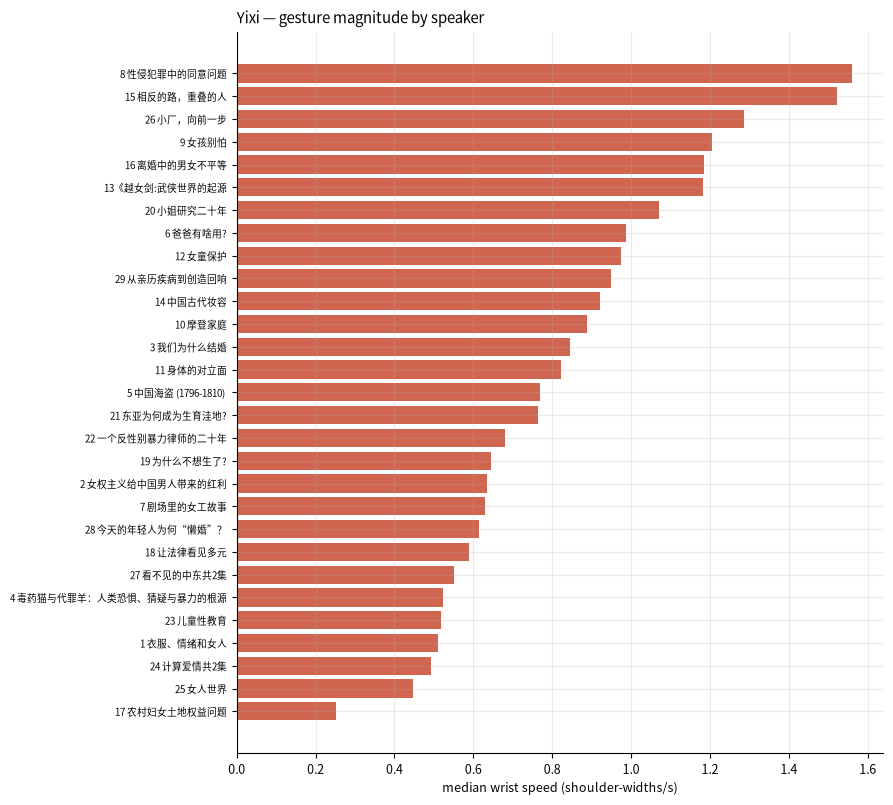

largest speaker median is 6.2x the smallest — individual differences remain after body normalisation


In [10]:
if HAS_DATA:
    by_video = (gest.groupby("job_id").wrist_speed_mean
                .agg(["median", "count"]).reset_index()
                .merge(videos[["job_id", "label"]], on="job_id", how="left")
                .sort_values("median"))
    by_video["label"] = by_video.label.fillna(by_video.job_id).map(short_label)

    fig, ax = plt.subplots(figsize=(9, max(3, 0.28 * len(by_video))))
    ax.barh(by_video.label, by_video["median"], color=MODALITY_COLOUR["gesture"], alpha=0.85)
    ax.set_xlabel("median wrist speed (shoulder-widths/s)")
    ax.set_title(f"{CORPUS} — gesture magnitude by speaker", loc="left")
    ax.tick_params(axis="y", labelsize=7)
    plt.tight_layout(); plt.show()

    spread = by_video["median"].max() / max(by_video["median"].min(), 1e-9)
    print(f"largest speaker median is {spread:.1f}x the smallest — "
          f"individual differences remain after body normalisation")

## 5. Pitch level and variation  — spec §4

Both measures are **relative to each speaker's own baseline**, as §4 requires:
an absolute Hz threshold would mostly sort speakers by voice type rather than
by discourse style.

* `pitch_st` — the window's mean f0 in **semitones** from that speaker's
  median. Semitones rather than z-scores because pitch is perceived
  logarithmically, so "+3 st" is the same perceptual step for any voice,
  whereas "+1 SD" depends on how variable that speaker happens to be.
* `pitch_level` / `pitch_variation` — **tertiles within each speaker**, so
  "high" means high *for them*.

The working assumption to test downstream: low + stable = authoritative /
assertive, high + variable = emotional / engaging.

### Mandarin is tonal, and this is where it bites

The assumption above was formulated for intonation languages. In Mandarin,
lexical tone is carried by f0, so a large share of the f0 movement inside any
5-second window is doing lexical work — distinguishing 妈 from 马 — rather than
expressing stance. Two consequences:

* `pitch_var_st` is **not the same construct** as in English. It is
  tone-plus-intonation here and intonation-alone there, so the two corpora's
  values must not be placed on one axis in notebook 03 without saying so.
* Within this corpus the measure is still usable, because every speaker is
  producing the same tonal inventory: a window that is variable *for this
  speaker* still reflects something beyond tone. That is an argument for the
  per-speaker tertiles, not for absolute values.

Separating tone from intonation would need syllable-aligned f0 and a tone
model. The dense contours from `scripts/backfill_dense_prosody.py` are the
prerequisite for that and are stored; the analysis is not built.

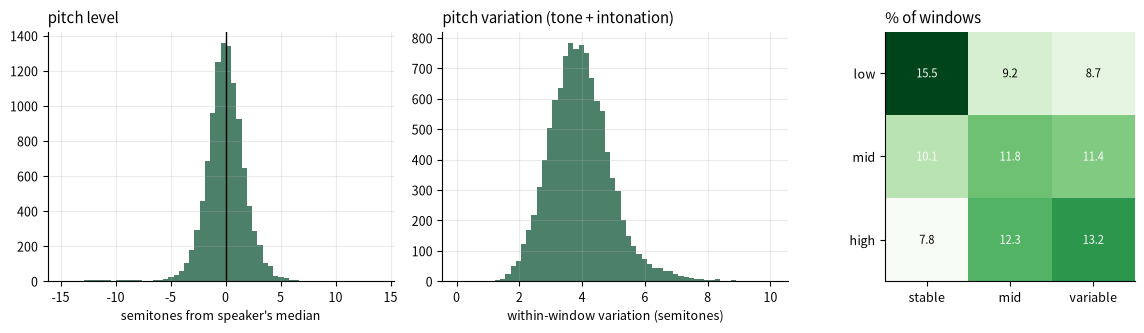

pitch in semitones from own median: median +0.00, 10th-90th [-2.04, +2.08]
within-window variation: median 3.89 st (read as tone + intonation, not intonation alone)

the two assumption corners (spec §4):
    low + stable     1664 windows (15.5%)   <- authoritative / assertive
   high + variable   1422 windows (13.2%)   <- emotional / engaging


In [11]:
if not HAS_DATA:
    print("skipped — no data")
else:
    dfp = dfg                 # pitch columns added by load_corpus
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

    axes[0].hist(dfp.pitch_st.dropna(), bins=60, color=MODALITY_COLOUR["prosody"], alpha=0.85)
    axes[0].set_xlabel("semitones from speaker's median"); axes[0].set_title("pitch level", loc="left")
    axes[0].axvline(0, color="k", lw=1)

    axes[1].hist(dfp.pitch_var_st.dropna(), bins=60, color=MODALITY_COLOUR["prosody"], alpha=0.85)
    axes[1].set_xlabel("within-window variation (semitones)")
    axes[1].set_title("pitch variation (tone + intonation)", loc="left")

    cross = (pd.crosstab(dfp.pitch_level, dfp.pitch_variation, normalize=True) * 100)
    cross = cross.reindex(index=["low", "mid", "high"], columns=["stable", "mid", "variable"])
    im = axes[2].imshow(cross.values, cmap="Greens")
    axes[2].set_xticks(range(3), cross.columns); axes[2].set_yticks(range(3), cross.index)
    axes[2].set_title("% of windows", loc="left"); axes[2].grid(False)
    for i in range(3):
        for j in range(3):
            v = cross.values[i, j]
            axes[2].text(j, i, f"{v:.1f}", ha="center", va="center",
                         color="white" if v > np.nanmax(cross.values) * 0.6 else "black", fontsize=8)
    plt.tight_layout(); plt.show()

    print("pitch in semitones from own median: "
          f"median {dfp.pitch_st.median():+.2f}, "
          f"10th-90th [{dfp.pitch_st.quantile(.1):+.2f}, {dfp.pitch_st.quantile(.9):+.2f}]")
    print(f"within-window variation: median {dfp.pitch_var_st.median():.2f} st "
          f"(read as tone + intonation, not intonation alone)")
    print("\nthe two assumption corners (spec §4):")
    tot = len(dfp.dropna(subset=["pitch_level", "pitch_variation"]))
    for lvl, var, reading in [("low", "stable", "authoritative / assertive"),
                              ("high", "variable", "emotional / engaging")]:
        n = int(((dfp.pitch_level == lvl) & (dfp.pitch_variation == var)).sum())
        print(f"   {lvl:>4} + {var:<9} {n:>5} windows ({n/tot:.1%})   <- {reading}")

### Speaker baselines

The absolute medians the relative measure is built on. Wide spread here is
exactly why §4 insists on speaker-relative measures — and note that in a mixed
corpus this axis largely reflects voice type, not style.

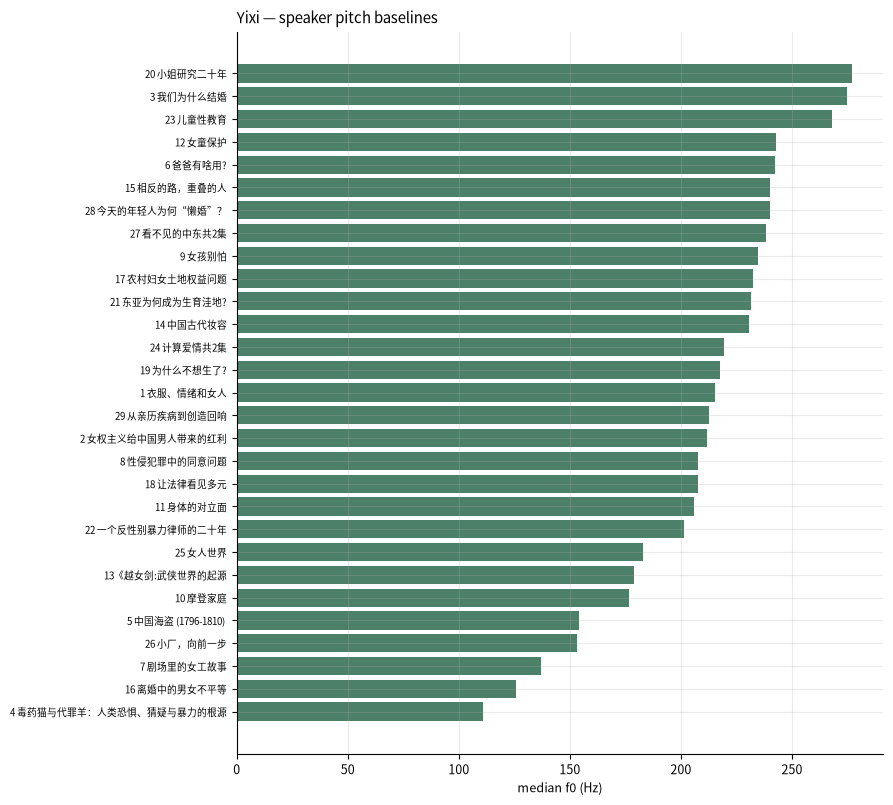

baselines span 111-277 Hz


In [12]:
if HAS_DATA:
    base = (dfp.groupby("job_id").mean_f0.median().reset_index()
            .merge(videos[["job_id", "label"]], on="job_id", how="left")
            .sort_values("mean_f0"))
    base["label"] = base.label.fillna(base.job_id).map(short_label)
    fig, ax = plt.subplots(figsize=(9, max(3, 0.28 * len(base))))
    ax.barh(base.label, base.mean_f0, color=MODALITY_COLOUR["prosody"], alpha=0.85)
    ax.set_xlabel("median f0 (Hz)"); ax.set_title(f"{CORPUS} — speaker pitch baselines", loc="left")
    ax.tick_params(axis="y", labelsize=7)
    plt.tight_layout(); plt.show()
    print(f"baselines span {base.mean_f0.min():.0f}-{base.mean_f0.max():.0f} Hz")

## 6. Shots and angles  — spec §3

Within-corpus distribution as percentages of classified windows. Two things to
keep in mind:

* These are **per-window dominant** labels, not per-shot-segment labels, so a
  window straddling a cut is attributed to whichever shot dominates it.
* Editing is a production choice. Differences between corpora here may say
  more about the broadcaster than about the speaker — and YiXi is a studio
  production with a fixed stage, so its distribution reflects one house style
  rather than the range TED's many venues produce.

Shots-per-minute normalisation and the EN–ZH chi-square are two-corpus
statistics and live in the comparative notebook.

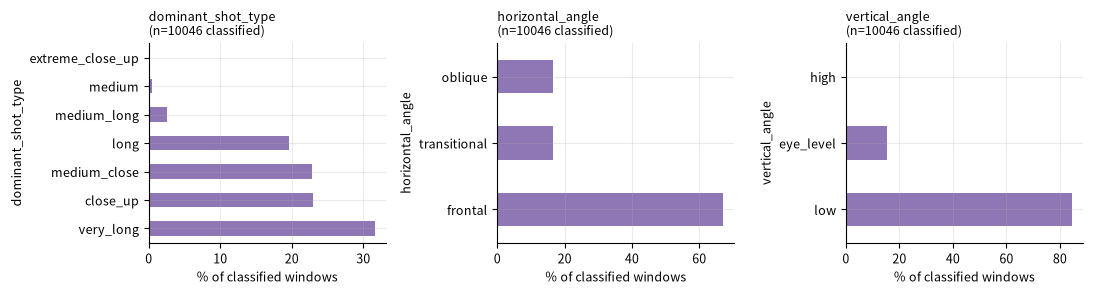


dominant_shot_type:
   very_long                3172  (29% of all windows)
   close_up                 2309  (21% of all windows)
   medium_close             2296  (21% of all windows)
   long                     1969  (18% of all windows)
   MISSING (unclassified)    783  (7% of all windows)
   medium_long               251  (2% of all windows)
   medium                     48  (0% of all windows)
   extreme_close_up            1  (0% of all windows)

horizontal_angle:
   frontal                  6740  (62% of all windows)
   transitional             1654  (15% of all windows)
   oblique                  1652  (15% of all windows)
   MISSING (unclassified)    783  (7% of all windows)

vertical_angle:
   low                      8480  (78% of all windows)
   eye_level                1560  (14% of all windows)
   MISSING (unclassified)    783  (7% of all windows)
   high                        6  (0% of all windows)

cuts per minute: median 5.6, range 3.0-12.4


In [13]:
if not HAS_DATA:
    print("skipped — no data")
else:
    cats = [c for c in ["dominant_shot_type", "horizontal_angle", "vertical_angle"] if c in df.columns]
    fig, axes = plt.subplots(1, len(cats), figsize=(11, 3))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, cats):
        vc = df[col].value_counts(dropna=True)
        if vc.empty:
            ax.text(0.5, 0.5, "no classified windows", ha="center", va="center"); ax.axis("off"); continue
        (vc / vc.sum() * 100).plot.barh(ax=ax, color=MODALITY_COLOUR["camera"], alpha=0.85)
        ax.set_title(f"{col}\n(n={int(vc.sum())} classified)", fontsize=9, loc="left")
        ax.set_xlabel("% of classified windows")
    plt.tight_layout(); plt.show()

    for col in cats:
        vc = df[col].value_counts(dropna=False)
        print(f"\n{col}:")
        for k, n in vc.items():
            k = "MISSING (unclassified)" if pd.isna(k) else k
            print(f"   {str(k):<24} {n:>4}  ({n/len(df):.0%} of all windows)")

    cuts = df.groupby("job_id").cut_count.sum()
    mins = videos.set_index("job_id").duration_s / 60
    cpm = (cuts / mins).dropna()
    print(f"\ncuts per minute: median {cpm.median():.1f}, range {cpm.min():.1f}-{cpm.max():.1f}")

## 7. Temporal trends — how a talk evolves

Per-window metrics against position in the talk (0 = start, 1 = end), averaged
across videos so talks of different lengths can be overlaid. Gesture uses the
**normalised** metric and speech rate the **counted** one, so nothing here is
in units this notebook has already rejected.

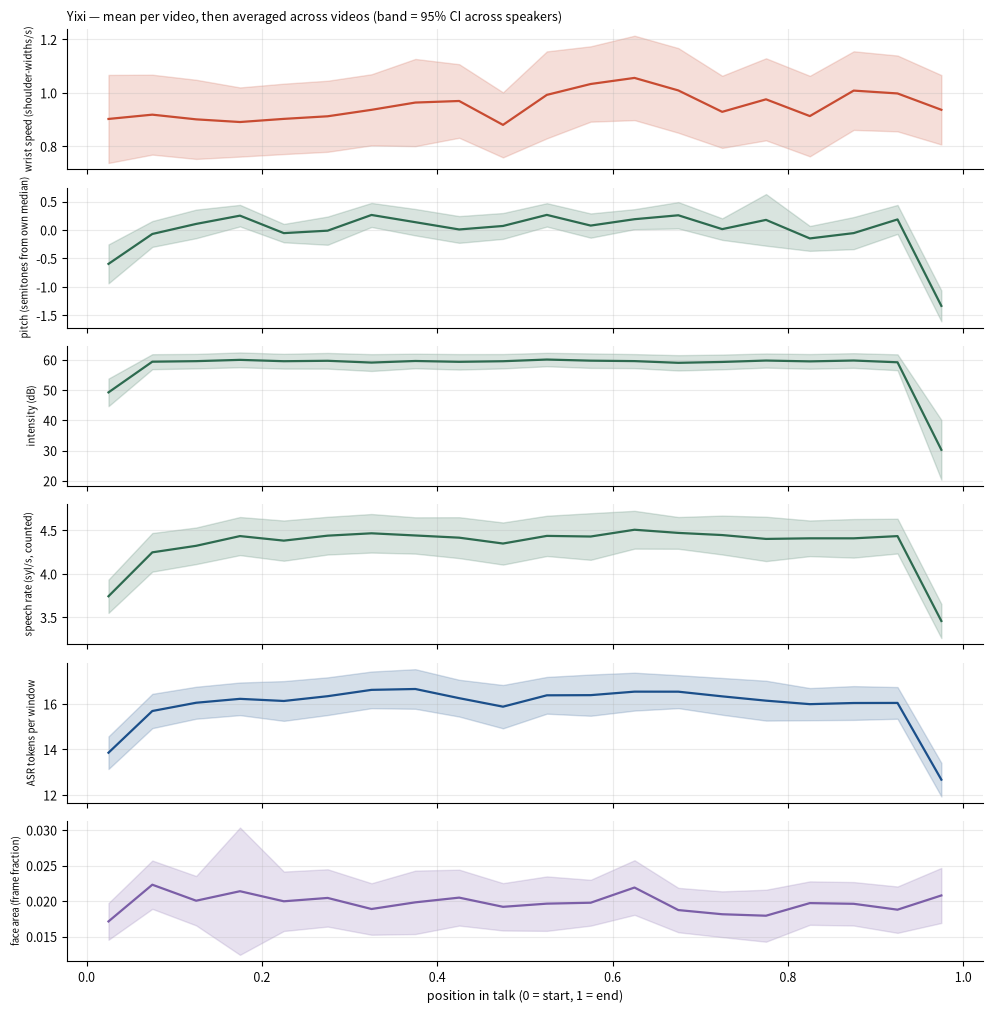

In [14]:
if not HAS_DATA:
    print("skipped — no data")
else:
    metrics = [
        ("wrist_speed_mean",    "gesture", "wrist speed (shoulder-widths/s)"),
        ("pitch_st",            "prosody", "pitch (semitones from own median)"),
        ("mean_intensity_db",   "prosody", "intensity (dB)"),
        ("speech_rate_syl_per_s", "prosody", "speech rate (syl/s, counted)"),
        ("word_count",          "verbal",  "ASR tokens per window"),
        ("mean_face_bbox_area", "camera",  "face area (frame fraction)"),
    ]
    metrics = [m for m in metrics if m[0] in dfp.columns and dfp[m[0]].notna().any()]

    bins = np.linspace(0, 1, 21)
    dfp["progress_bin"] = pd.cut(dfp.progress, bins, labels=(bins[:-1] + 0.025))

    fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 1.7 * len(metrics)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (col, mod, label) in zip(axes, metrics):
        per_video = dfp.groupby(["job_id", "progress_bin"], observed=True)[col].mean()
        curve = per_video.groupby("progress_bin", observed=True).agg(["mean", "sem"])
        x = curve.index.astype(float)
        ax.plot(x, curve["mean"], color=MODALITY_COLOUR[mod], lw=1.6)
        ax.fill_between(x, curve["mean"] - 1.96 * curve["sem"],
                        curve["mean"] + 1.96 * curve["sem"],
                        color=MODALITY_COLOUR[mod], alpha=0.18)
        ax.set_ylabel(label, fontsize=7)
    axes[-1].set_xlabel("position in talk (0 = start, 1 = end)")
    axes[0].set_title(f"{CORPUS} — mean per video, then averaged across videos "
                      f"(band = 95% CI across speakers)", loc="left", fontsize=9)
    plt.tight_layout(); plt.show()

## 8. Summary table

One row per measure, in the units this notebook standardises on. This is the
table to quote from. Two stored columns are deliberately absent: the
pixel-based gesture metric, and `speech_rate_syl_per_s`.

In [15]:
if HAS_DATA:
    summary = []
    spec = [
        ("gesture", "wrist speed (shoulder-widths/s)", "wrist_speed_mean"),
        ("gesture", "pose coverage (ratio)",           "pose_present_ratio"),
        ("prosody", "pitch (semitones from median)",   "pitch_st"),
        ("prosody", "pitch variation (semitones)*",    "pitch_var_st"),
        ("prosody", "intensity (dB)",                  "mean_intensity_db"),
        ("prosody", "speech rate (syl/s, counted)",    "speech_rate_syl_per_s"),
        ("verbal",  "ASR tokens per window",           "word_count"),
        ("camera",  "cuts per window",                 "cut_count"),
        ("camera",  "face area (frame fraction)",      "mean_face_bbox_area"),
    ]
    for mod, label, col in spec:
        if col not in dfp.columns:
            continue
        s = dfp[col].dropna()
        if s.empty:
            continue
        summary.append({"modality": mod, "measure": label, "n windows": len(s),
                        "median": round(s.median(), 3),
                        "IQR": f"{s.quantile(.25):.2f}–{s.quantile(.75):.2f}",
                        "% of all windows": f"{len(s)/len(dfp):.0%}"})
    display(pd.DataFrame(summary))
    print("* tone + intonation; not comparable with an intonation-language corpus")

,modality,measure,n windows,median,IQR,% of all windows
0,gesture,wrist speed (shoulder-widths/s),9928,0.788,0.52–1.20,92%
1,gesture,pose coverage (ratio),10829,1.000,1.00–1.00,100%
2,prosody,pitch (semitones from median),10751,0.000,-1.01–1.03,99%
3,prosody,pitch variation (semitones)*,10751,3.886,3.28–4.52,99%
4,prosody,intensity (dB),10829,60.117,55.44–65.95,100%
5,prosody,"speech rate (syl/s, counted)",10829,4.400,3.60–5.00,100%
6,verbal,ASR tokens per window,10829,16.000,13.00–18.00,100%
7,camera,cuts per window,10829,0.000,0.00–1.00,100%
8,camera,face area (frame fraction),9668,0.018,0.01–0.02,89%


* tone + intonation; not comparable with an intonation-language corpus


## 9. Reading these results

* **Always read a number against its coverage.** Gesture measures exist only
  where a pose was tracked; the "% of all windows" column in section 8 is the
  honest denominator.
* **Gesture is in body units**, and section 4's confound check is the evidence
  for preferring them to the stored pixel figure. This section is the one that
  transfers between the two corpora unchanged.
* **Pitch is speaker-relative by construction**, so `pitch_st` cannot be
  compared against another corpus' raw Hz. `pitch_var_st` additionally carries
  lexical tone here, so it cannot be compared against an intonation language's
  variation either, even in relative units.
* **Speech rate is counted, not assumed** — Han characters per second, stored
  correctly since the verbal backfill. English still uses an assumed
  syllables-per-word ratio, so the two corpora need a common estimator before
  they can be compared on this axis.
* **Word frequencies are per 1,000 segmented words**, and the segmenter is part
  of the result. Quote `n_videos` alongside any count; §7.2's principle — never
  a percentage without its n — applies here just as much as in the search bar.
* **Do not split a frequency by part of speech.** The stored tag is the tag of
  the word's first occurrence in that video, so a per-tag count is an artefact
  of where in the talk the word first appeared.
* **Nothing here is a comparison.** Keyness, the shot chi-square and the concept
  mapping are two-corpus statistics; cross-modal correlation is in notebook 04.